In [1]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

D:\Anaconda\envs\AI\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
img_height = 224
img_width = 224
batch_size = 16
seed = 123

In [3]:
train_data = tf.keras.utils.image_dataset_from_directory(
    "Fruit1/train",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True,
    seed=seed
)

val_data = tf.keras.utils.image_dataset_from_directory(
    "Fruit1/val",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)

Found 5600 files belonging to 8 classes.
Found 1600 files belonging to 8 classes.


In [4]:
class_names = train_data.class_names

# --- Convert train to numpy ---
X_train, y_train = [], []
for images, labels in train_data:
    X_train.append(images.numpy())
    y_train.append(labels.numpy())
X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)

# --- Convert val to numpy ---
X_test, y_test = [], []
for images, labels in val_data:
    X_test.append(images.numpy())
    y_test.append(labels.numpy())
X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

# --- Inspect ---
print(f'Training images shape : {X_train.shape}')
print(f'Training labels shape : {y_train.shape}')
print(f'Test images shape     : {X_test.shape}')
print(f'Test labels shape     : {y_test.shape}')
print(f'Pixel value range     : {X_train.min()} to {X_train.max()}')
print(f'Number of classes     : {len(class_names)}')
print(f'Number of classes     : {len(class_names)}')

Training images shape : (5600, 224, 224, 3)
Training labels shape : (5600, 8)
Test images shape     : (1600, 224, 224, 3)
Test labels shape     : (1600, 8)
Pixel value range     : 0.0 to 255.0
Number of classes     : 8
Number of classes     : 8


In [5]:
class_names = train_data.class_names
num_classes = len(class_names)
print("✅ Classes:", class_names)
print("✅ Number of classes:", num_classes)

✅ Classes: ['Apple', 'Avocado', 'Banana', 'Grapes', 'Mangosteen', 'Orange', 'Pineapple', 'Pomegranate']
✅ Number of classes: 8


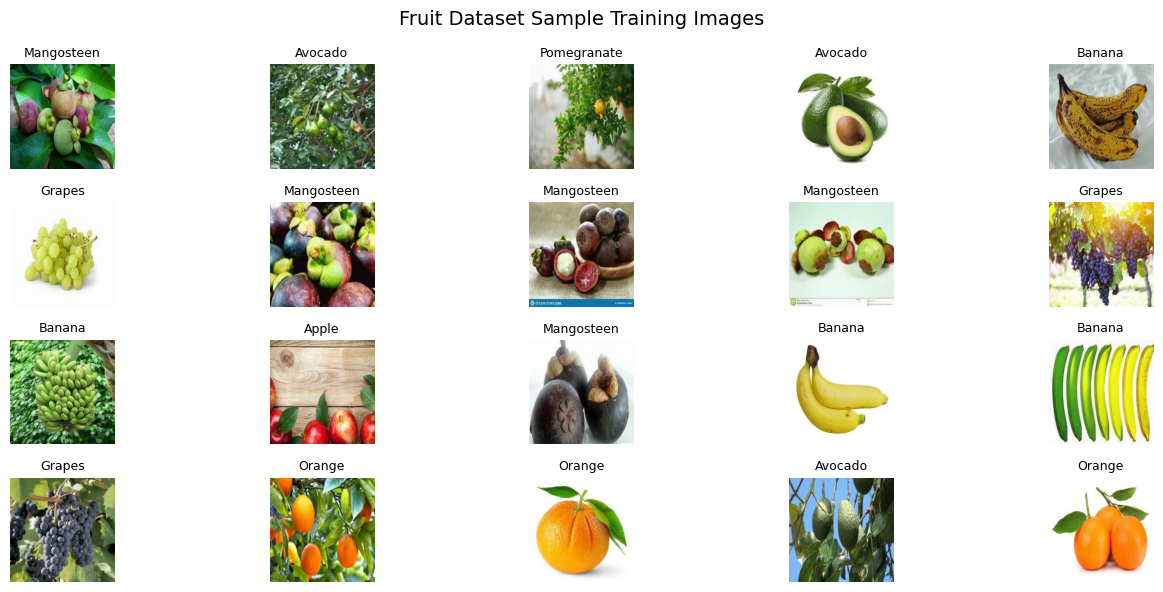

In [6]:
plt.figure(figsize=(14, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train[i].astype("uint8"))
    plt.title(class_names[np.argmax(y_train[i])], fontsize=9)
    plt.axis('off')

plt.suptitle('Fruit Dataset Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

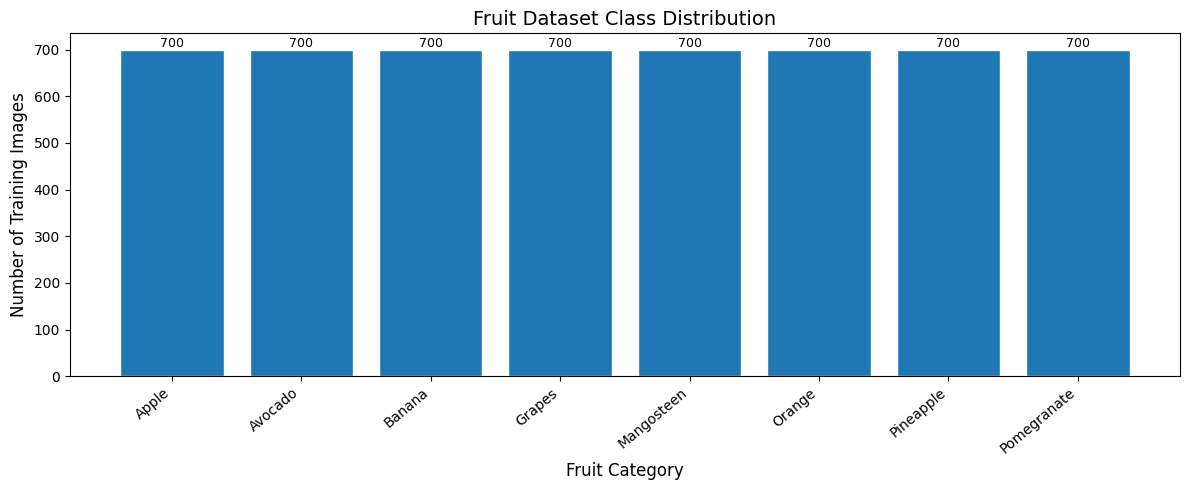


Images per class:
  Apple          : 700
  Avocado        : 700
  Banana         : 700
  Grapes         : 700
  Mangosteen     : 700
  Orange         : 700
  Pineapple      : 700
  Pomegranate    : 700


In [7]:
# Convert one-hot labels to class index
y_train_labels = np.argmax(y_train, axis=1)

unique, counts = np.unique(y_train_labels, return_counts=True)

plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, counts, edgecolor='white')

plt.xlabel('Fruit Category', fontsize=12)
plt.ylabel('Number of Training Images', fontsize=12)
plt.title('Fruit Dataset Class Distribution', fontsize=14)
plt.xticks(rotation=40, ha='right')

# Add count labels
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             str(count),
             ha='center',
             fontsize=9)

plt.tight_layout()
plt.show()

print('\nImages per class:')
for name, count in zip(class_names, counts):
    print(f'  {name:<14} : {count:,}')

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.map(
    lambda x, y: (x / 255.0, y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)

val_data = val_data.map(
    lambda x, y: (x / 255.0, y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)

In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [10]:
model = tf.keras.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), activation="relu",input_shape=(img_height, img_width, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(num_classes, activation="softmax")
])

D:\Anaconda\envs\AI\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=4,
        min_lr=1e-6
    )
]

In [13]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    callbacks=callbacks
)

Epoch 1/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 234s 660ms/step - accuracy: 0.4468 - loss: 1.8004 - val_accuracy: 0.1300 - val_loss: 3.6431 - learning_rate: 3.0000e-04
Epoch 2/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 247s 702ms/step - accuracy: 0.5654 - loss: 1.3597 - val_accuracy: 0.6750 - val_loss: 0.9467 - learning_rate: 3.0000e-04
Epoch 3/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 241s 688ms/step - accuracy: 0.6161 - loss: 1.1718 - val_accuracy: 0.6875 - val_loss: 0.9077 - learning_rate: 3.0000e-04
Epoch 4/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 233s 666ms/step - accuracy: 0.6323 - loss: 1.0877 - val_accuracy: 0.5975 - val_loss: 1.3317 - learning_rate: 3.0000e-04
Epoch 5/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 234s 668ms/step - accuracy: 0.6500 - loss: 1.0641 - val_accuracy: 0.7437 - val_loss: 0.7383 - learning_rate: 3.0000e-04
Epoch 6/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 222s 635ms/step - accuracy: 0.6837 - loss: 0.9355 - val_accuracy: 0.7563 - val_loss: 0.7027 - learning_rate: 3.0000e-04
Epoch 7/100
350/350 ━━━━━━━━━━━━━━

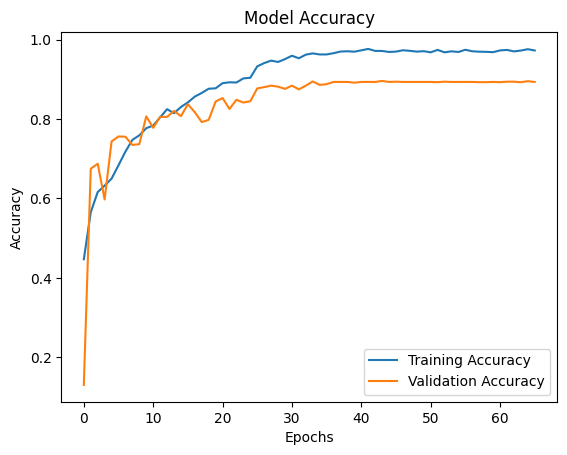

In [14]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.show()

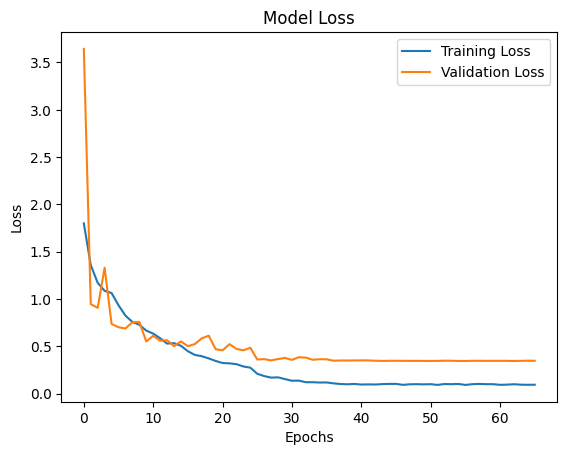

In [15]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.show()

In [16]:
model.save("CNN_MODEL_FRUIT_CLASSIFICATION_v2.h5")

In [17]:
import json
with open("Trained_History_PROJECT_FRUIT_v2.json",'w') as f:
    json.dump(history.history,f)

In [22]:
# test_datagen = ImageDataGenerator(rescale=1./255)

In [19]:
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    'Fruit1/test/',
    labels='inferred',
    label_mode='categorical',
    image_size=(224, 224),
    batch_size=8,
    shuffle=False
)

test_data = test_data.map(lambda x, y: (x/255.0, y))

val_loss, val_acc = model.evaluate(test_data)
val_acc = val_acc *100
print(f"Test Accuracy: {val_acc:.2f}")

Found 800 files belonging to 8 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.8863 - loss: 0.3592
Test Accuracy: 88.63


In [20]:
# Evaluate directly on dataset
test_loss, test_accuracy = model.evaluate(test_data, verbose=0)

print('=' * 55)
print('  FINAL TEST SET RESULTS')
print('=' * 55)
print(f'  Test Accuracy : {test_accuracy * 100:.2f}%')
print(f'  Test Loss     : {test_loss:.4f}')
print('=' * 55)

# Collect all true labels
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in test_data])

# Predict probabilities for all images
y_prob = model.predict(test_data, verbose=0)

# Predicted labels
y_pred = np.argmax(y_prob, axis=1)

idx = 0
print(f'\nExample Prediction (Test image {idx}):')
print(f'  True label  : {y_true[idx]} ({class_names[y_true[idx]]})')
print(f'  Predicted   : {y_pred[idx]} ({class_names[y_pred[idx]]})')
print(f'  Confidence  : {y_prob[idx][y_pred[idx]] * 100:.1f}%')

  FINAL TEST SET RESULTS
  Test Accuracy : 88.63%
  Test Loss     : 0.3592

Example Prediction (Test image 0):
  True label  : 0 (Apple)
  Predicted   : 0 (Apple)
  Confidence  : 99.7%


In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
print('\nDetailed Classification Report')
print('=' * 70)
print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=3
))


Detailed Classification Report
              precision    recall  f1-score   support

       Apple      0.810     0.680     0.739       100
     Avocado      0.869     0.930     0.899       100
      Banana      0.899     0.890     0.894       100
      Grapes      0.860     0.920     0.889       100
  Mangosteen      0.890     0.890     0.890       100
      Orange      0.989     0.940     0.964       100
   Pineapple      0.950     0.950     0.950       100
 Pomegranate      0.824     0.890     0.856       100

    accuracy                          0.886       800
   macro avg      0.886     0.886     0.885       800
weighted avg      0.886     0.886     0.885       800



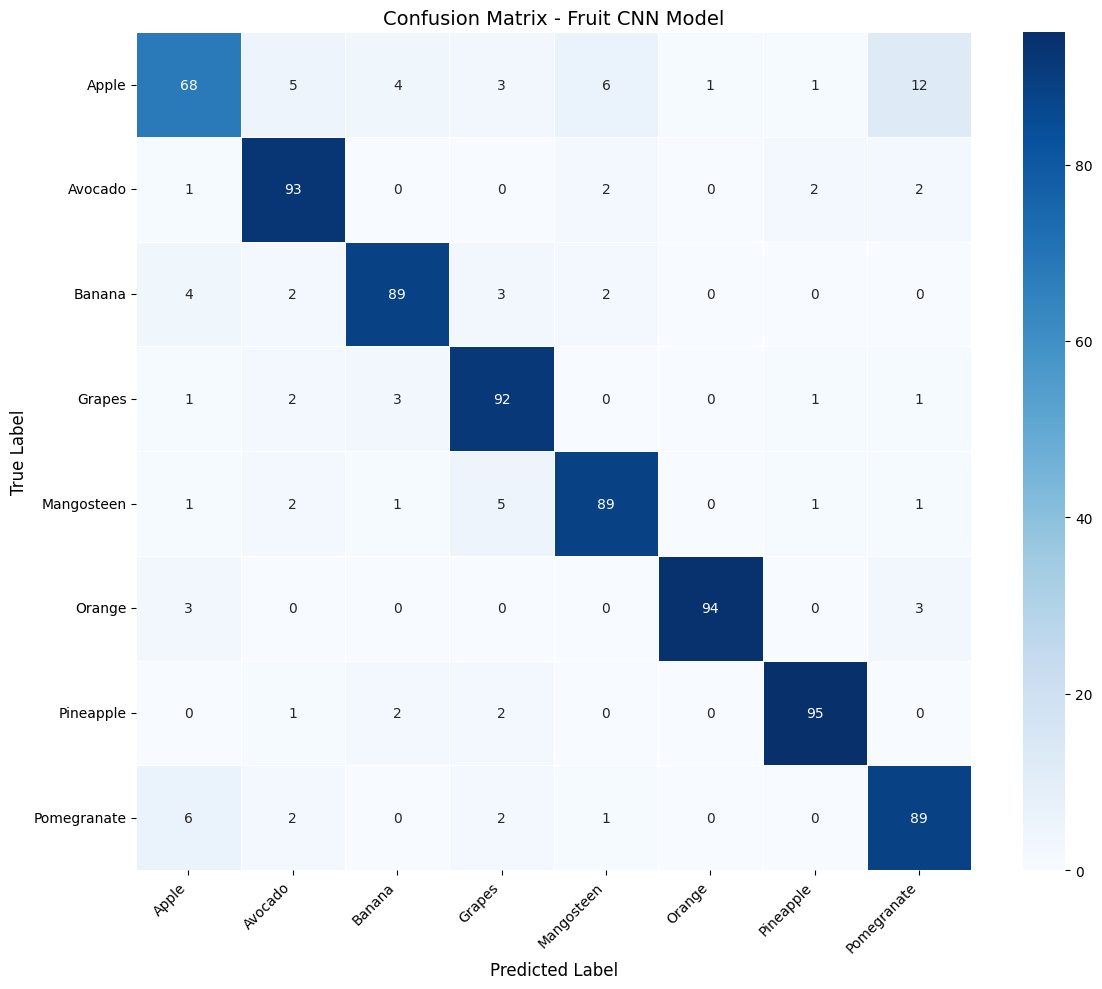

In [22]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Fruit CNN Model', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
print('\nMost Common Misclassifications (> 10 occurrences):')
print('-' * 60)

num_classes = len(class_names)

for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 10:   # threshold adjustable
            print(f'  {class_names[i]:<15} misclassified as '
                  f'{class_names[j]:<15} : {cm[i,j]} times')


Most Common Misclassifications (> 10 occurrences):
------------------------------------------------------------
  Apple           misclassified as Pomegranate     : 12 times


In [11]:
model = tf.keras.models.load_model("CNN_MODEL_FRUIT_CLASSIFICATION_v2.h5")

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Load and preprocess the image
img = image.load_img(r"image.jpg", target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array)

# Get predicted class index
class_index = np.argmax(prediction)

# Map to class labels
class_labels = list(train_data.class_indices.keys())
predicted_class = class_labels[class_index]

# Get confidence for the predicted class
confidence = prediction[0][class_index] * 100


plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()